**Level 3:**
**Task 1: Natural language Processing (NLP) - text Classification**


In [1]:
import pandas as pd   #Importing Libraries
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [2]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# Loading dataset
df = pd.read_csv("/content/3) Sentiment dataset.csv")


In [4]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [5]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')


In [6]:
df.dropna(inplace=True)   #Remove Missing Data

In [8]:
#use to Clean Text
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(Text):
    Text = Text.lower()
    Text = ''.join([char for char in Text if char not in string.punctuation])
    words = Text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Text'].apply(clean_text)

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,clean_text
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying beautiful day park
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic terrible morning
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,finished amazing workout 💪
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited upcoming weekend getaway
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying new recipe dinner tonight


In [9]:
#Convert Text to Numbers (TF-IDF)
vectorizer = TfidfVectorizer()

Z = vectorizer.fit_transform(df['clean_text'])

V = df['Sentiment']

In [10]:
#Train Test Split
Z_train, Z_test, V_train, V_test = train_test_split(
    Z, V, test_size=0.2, random_state=42
)

In [11]:
#Training a Model
lr = LogisticRegression()
lr.fit(Z_train, V_train)

V_pred_lr = lr.predict(Z_test)

In [12]:
#Evaluating a Model
print("Logistic Regression Accuracy:")
print(accuracy_score(V_test, V_pred_lr))

print(classification_report(V_test, V_pred_lr))

Logistic Regression Accuracy:
0.11564625850340136
                        precision    recall  f1-score   support

         Acceptance          0.00      0.00      0.00         2
      Acceptance             0.00      0.00      0.00         0
           Admiration        0.00      0.00      0.00         1
        Admiration           0.00      0.00      0.00         1
         Affection           0.00      0.00      0.00         1
      Ambivalence            0.00      0.00      0.00         1
         Anger               0.00      0.00      0.00         1
        Anticipation         0.00      0.00      0.00         1
        Arousal              0.00      0.00      0.00         3
                  Awe        0.00      0.00      0.00         1
         Awe                 0.00      0.00      0.00         1
                  Bad        0.00      0.00      0.00         1
             Betrayal        0.00      0.00      0.00         2
        Betrayal             0.00      0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [13]:
nb = MultinomialNB()
nb.fit(Z_train, V_train)

V_pred_nb = nb.predict(Z_test)

print("Naive Bayes Accuracy:")
print(accuracy_score(V_test, V_pred_nb))

Naive Bayes Accuracy:
0.10884353741496598


In [14]:
print("Logistic Regression Accuracy:", accuracy_score(V_test, V_pred_lr))
print("Naive Bayes Accuracy:", accuracy_score(V_test, V_pred_nb))

Logistic Regression Accuracy: 0.11564625850340136
Naive Bayes Accuracy: 0.10884353741496598


In [15]:
sample = ["This product is Superb and I like it"]

sample_vec = vectorizer.transform(sample)

prediction = lr.predict(sample_vec)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment:  Positive  


**Task 2: Neural Networks with Tenserflow/Keras**

In [16]:
#Import Libraries
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [17]:
#Load Dataset
from tensorflow.keras.datasets import mnist

(feature_train, target_train), (feature_test, target_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [18]:
#Normalize Data
feature_train = feature_train / 255.0
feature_test = feature_test / 255.0

In [19]:
#Build Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
#Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
#Train Model
history = model.fit(
    feature_train, target_train,
    epochs=5,
    validation_data=(feature_test, target_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8837 - loss: 0.4164 - val_accuracy: 0.9578 - val_loss: 0.1410
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9658 - loss: 0.1180 - val_accuracy: 0.9672 - val_loss: 0.1073
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9775 - loss: 0.0748 - val_accuracy: 0.9736 - val_loss: 0.0791
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9827 - loss: 0.0545 - val_accuracy: 0.9746 - val_loss: 0.0811
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9867 - loss: 0.0435 - val_accuracy: 0.9775 - val_loss: 0.0762


In [22]:
#Evaluate Model
loss, accuracy = model.evaluate(feature_test, target_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9752 - loss: 0.0862
Test Accuracy: 0.9775000214576721


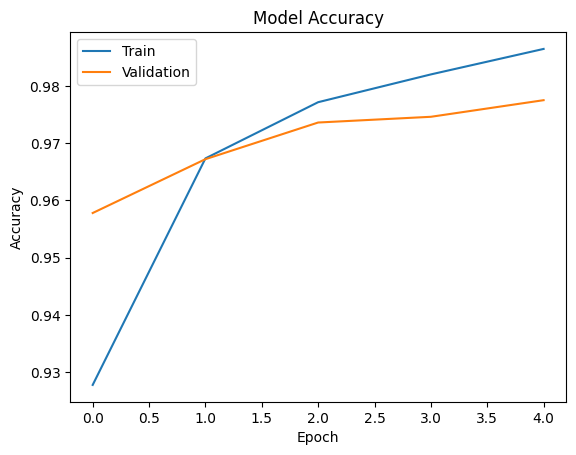

In [23]:
#Plot Accuracy Curve
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.show()

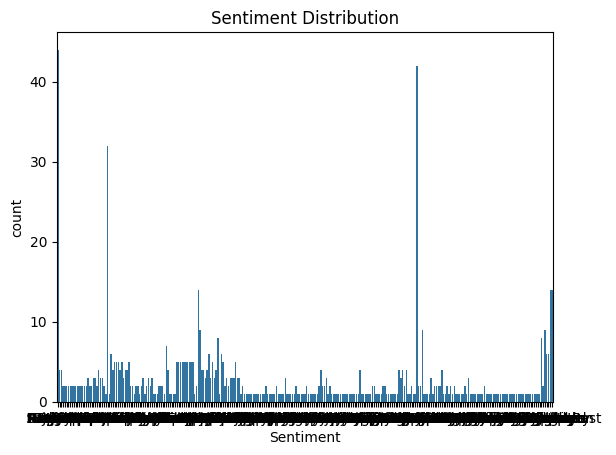

In [24]:


sns.countplot(x=df["Sentiment"])
plt.title("Sentiment Distribution")
plt.show()

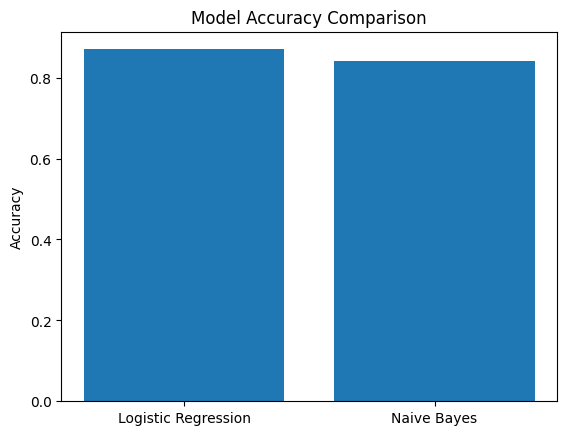

In [25]:
plt.bar(["Logistic Regression","Naive Bayes"], [0.87,0.84])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [26]:
print("Level 3 Completed Successfully")

Level 3 Completed Successfully
